# DATA ANALYSIS ON OCCURENCE OF MALARIA ACROSS THE WORLD

## Problem Statement
- Rampant malaria cases have become a threat to population across the world which causes death in severe cases
- African nations experience higher cases of malaria compared to other WHO regions

## Aim of the project
- Understanding the trend of Malaria cases with years so as to understand the effectiveness of preventive measures employed.
- To analyse the probability malaria deaths in relation with malaria cases

## Data understanding
This is a dataset of malaria and related information from https://www.kaggle.com/datasets/imdevskp/malaria-dataset
### columns interpretation ;
- ***Country*** -these are Nations where malaria cases are registered
- ***Year*** -these are years along which malaria cases are registered with time
- ***No. of cases*** -number of malaria cases registered
- ***No. of deaths*** -number of malaria deaths registered
- ***No. of cases_median*** - moderate of number of malaria cases registered
- ***No. of cases_min*** -minimum number malaria cases registered
- ***No. of cases_max*** -maximum number malaria cases registered
- ***No. of deaths_median*** -moderate of number of malaria deaths registered
- ***No. of deaths_min*** -minimum number malaria deaths registered
- ***No. of deaths_max*** -maximum number malaria deaths registered
- ***WHO Region*** -Regions of the world where malaria occur

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [21]:
#reading of a csv file using pandas
fd=pd.read_csv("PROJECT_2.csv")

In [22]:
#to show the first five rows of the dataset
fd.head()

,Country,Year,No. of cases,No. of deaths,No. of cases_median,No. of cases_min,No. of cases_max,No. of deaths_median,No. of deaths_min,No. of deaths_max,WHO Region
0,Afghanistan,2017,630308[495000-801000],298[110-510],630308,495000.0,801000.0,298,110.0,510.0,Eastern Mediterranean
1,Algeria,2017,0,0,0,NaN,NaN,0,NaN,NaN,Africa
2,Angola,2017,4615605[3106000-6661000],13316[9970-16600],4615605,3106000.0,6661000.0,13316,9970.0,16600.0,Africa
3,Argentina,2017,0,0,0,NaN,NaN,0,NaN,NaN,Americas
4,Armenia,2017,0,0,0,NaN,NaN,0,NaN,NaN,Europe


In [23]:
#overall assessment of the dataset(columns,data types,sum of null values)
fd.info()

<class 'pandas.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               856 non-null    str    
 1   Year                  856 non-null    int64  
 2   No. of cases          856 non-null    str    
 3   No. of deaths         856 non-null    str    
 4   No. of cases_median   856 non-null    int64  
 5   No. of cases_min      544 non-null    float64
 6   No. of cases_max      544 non-null    float64
 7   No. of deaths_median  856 non-null    int64  
 8   No. of deaths_min     524 non-null    float64
 9   No. of deaths_max     524 non-null    float64
 10  WHO Region            856 non-null    str    
dtypes: float64(4), int64(3), str(4)
memory usage: 73.7 KB


In [24]:
#show the columns
fd.columns

Index(['Country', 'Year', 'No. of cases', 'No. of deaths',
       'No. of cases_median', 'No. of cases_min', 'No. of cases_max',
       'No. of deaths_median', 'No. of deaths_min', 'No. of deaths_max',
       'WHO Region'],
      dtype='str')

## Data cleaning

In [25]:
#total null values per column
fd.isnull().sum()

Country                   0
Year                      0
No. of cases              0
No. of deaths             0
No. of cases_median       0
No. of cases_min        312
No. of cases_max        312
No. of deaths_median      0
No. of deaths_min       332
No. of deaths_max       332
WHO Region                0
dtype: int64

In [26]:
#removing all rows containing null values
fd=fd.dropna(subset=["No. of cases_min","No. of cases_max","No. of deaths_min","No. of deaths_max"])
print(fd)

                                Country  Year              No. of cases  \
0                           Afghanistan  2017     630308[495000-801000]   
2                                Angola  2017  4615605[3106000-6661000]   
6                            Bangladesh  2017        32924[30000-36000]   
8                                 Benin  2017  4111699[2774000-6552000]   
10     Bolivia (Plurinational State of)  2017           6512[4900-8300]   
..                                  ...   ...                       ...   
851  Venezuela (Bolivarian Republic of)  2010        57257[47000-74000]   
852                            Viet Nam  2010        23062[21000-26000]   
853                               Yemen  2010   1134927[611000-2686000]   
854                              Zambia  2010  2169307[1449000-3095000]   
855                            Zimbabwe  2010   1095083[606000-1717000]   

         No. of deaths  No. of cases_median  No. of cases_min  \
0         298[110-510]            

In [27]:
#checking number of duplicates
fd.duplicated().sum()

np.int64(0)

In [28]:
fd.to_csv("cleaned_project_2.csv",index=False)

## Data visualization

In [29]:
#importing the libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Text(0.5, 1.0, 'Distribution of Malaria across the world')

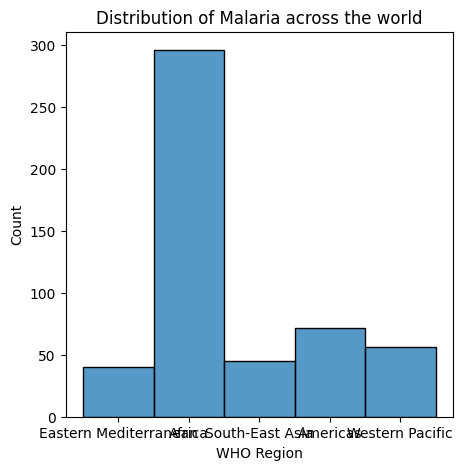

In [35]:
#plotting a histogram using seaborn
plt.figure(figsize=(5,5))
sns.histplot(x="WHO Region",data=fd)
plt.title("Distribution of Malaria across the world")

### Findings
- Africa as part of WHO has registered the highest count of malaria cases
- Eastern Mediterranean has registered the lowest number of malaria cases in WHO

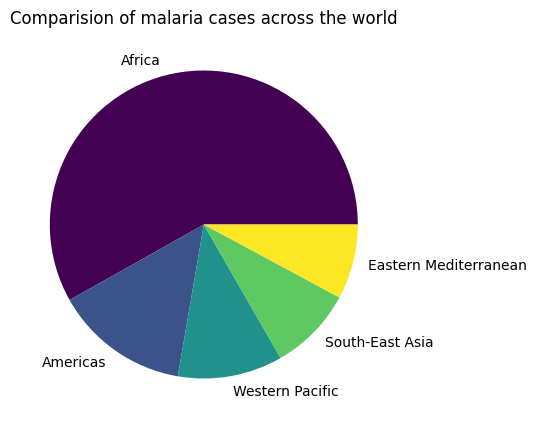

In [39]:
#plotting a pie chart
plt.Figure(figsize=(6,8))
case_median=fd['WHO Region'].value_counts()
case_median.plot(kind='pie',cmap="viridis", figsize=(5,5))
plt.title('Comparision of malaria cases across the world')
plt.show()

### Findings
- Africa as part of WHO has registered the highest count of malaria cases
- Eastern Mediterranean has registered the lowest number of malaria cases in WHO


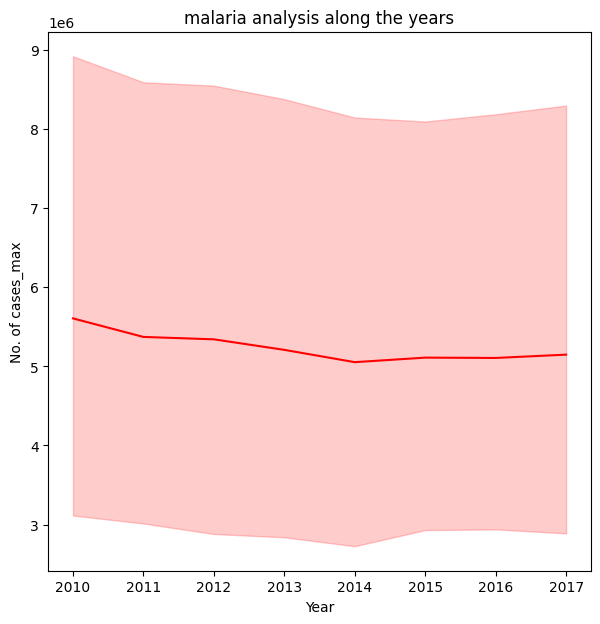

In [42]:
#plotting a line graph using seaborn
plt.figure(figsize=(7,7))
sns.lineplot(x="Year",y="No. of cases_max",data=fd,color="red")
plt.title("malaria analysis along the years")
plt.show()

### Findings
- In 2010 ,the number of malaria cases was high which dropped slightly in 2011
- With years passing the number of malaria cases kept reducing until 2015 which slightly rose and remained constant

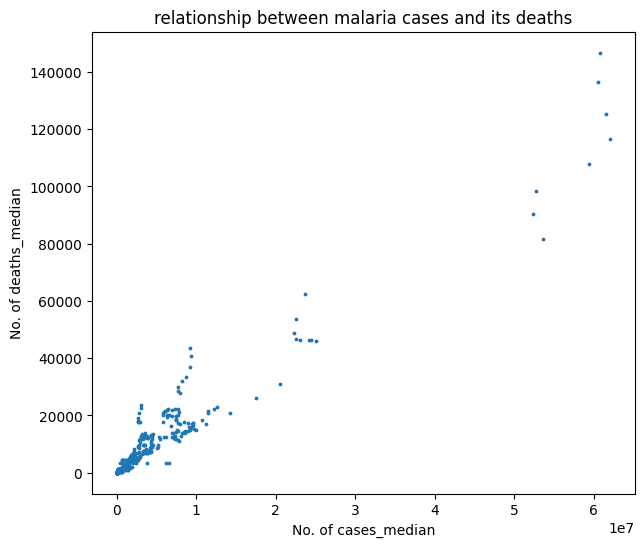

In [33]:
#plotting a scatterplot with matplotlib
plt.figure(figsize=(7,6))
plt.scatter(fd["No. of cases_median"],fd["No. of deaths_median"],s=3.0)
plt.title("relationship between malaria cases and its deaths")
plt.xlabel("No. of cases_median")
plt.ylabel("No. of deaths_median")
plt.show()

### Findings
- The lower the median of malaria cases the lower the median of malaria deaths
- The higher the median of malaria cases the higher the median of malaria deaths 

<Figure size 700x700 with 0 Axes>

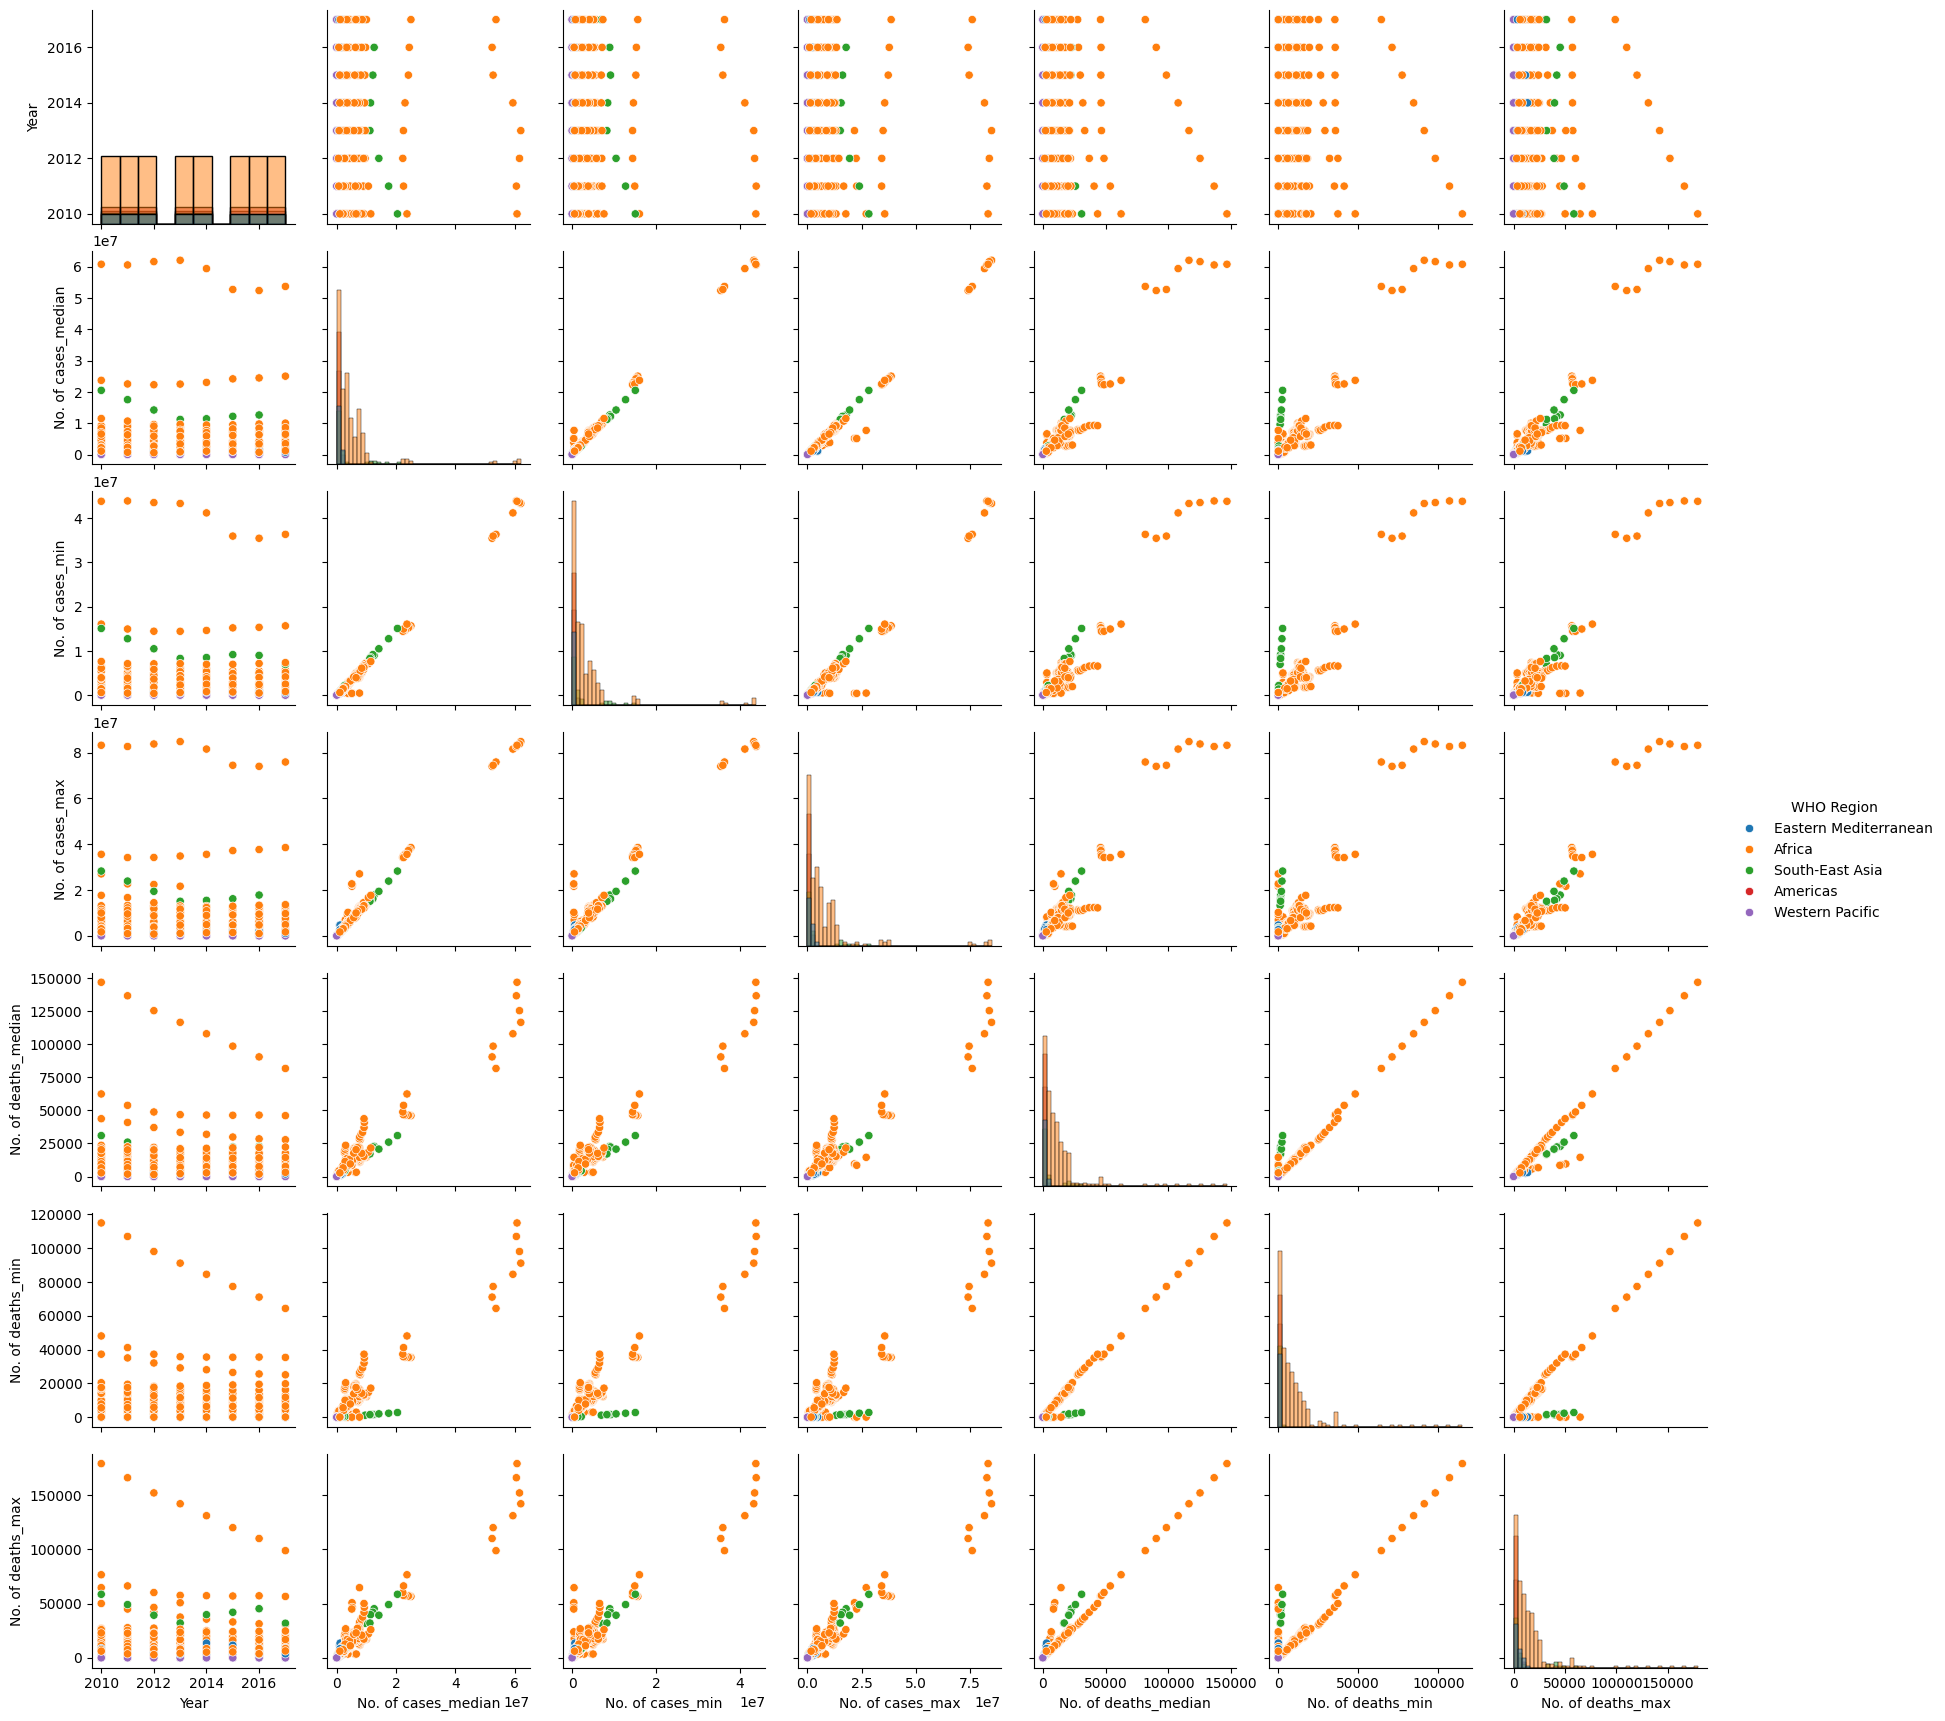

In [43]:
#plotting a pairplot
plt.figure(figsize=(7,7))
sns.pairplot(fd,hue="WHO Region",diag_kind="hist")
plt.show()


### Findings
- Africa as part of WHO has the highest median of malaria cases and deaths
- The median for malaria cases is directly proportional to the median for malaria deaths

## Conclusions
### Trend
- malaria cases reduced gradually since 2010 upto 2014 ,then slightly rose in 2015 which from then remained constant

### Relatinship between malaria cases and its deaths
- Malaria deaths are directly proportional to malaria cases

## Recommendations
- preventive methods employed in 2010 should be implemented seriously as their neglect in
 in 2014 led to rise of malaria cases 2015 which then remained constant
- preventive measures has to be prioritised as compared to curing due the correlation leading 
 to higher deaths with increase in malaria cases